In [1]:
# LIBRARIES, FUNCTIONS, AND INITIALIZATIONS

# Libraries
from colorama import Back, Style
import matplotlib.pyplot as plt
from tabulate import tabulate
import pandas as pd
import numpy as np
import sys

# Find reverse complement
def reverse_complement(sequence):
    sequence, newSequence = sequence.lower(), ''
    for i in range(0,len(sequence)):
        # Unambiguous
        if sequence[i] == 'a': newSequence = newSequence + 't'
        elif sequence[i] == 'c': newSequence = newSequence + 'g'
        elif sequence[i] == 'g': newSequence = newSequence + 'c'
        elif sequence[i] == 't': newSequence = newSequence + 'a'
        # Ambiguous
        elif sequence[i] == 'r': newSequence = newSequence + 'y'
        elif sequence[i] == 'y': newSequence = newSequence + 'r'
        elif sequence[i] == 'k': newSequence = newSequence + 'm'
        elif sequence[i] == 'm': newSequence = newSequence + 'k'
        elif sequence[i] == 's': newSequence = newSequence + 's'
        elif sequence[i] == 'w': newSequence = newSequence + 'w'
        elif sequence[i] == 'b': newSequence = newSequence + 'v'
        elif sequence[i] == 'd': newSequence = newSequence + 'h'
        elif sequence[i] == 'h': newSequence = newSequence + 'd'
        elif sequence[i] == 'v': newSequence = newSequence + 'b'
        elif sequence[i] == 'n': newSequence = newSequence + 'n'
    newSequence = newSequence[::-1]
    return newSequence

# Disambiguate DNA sequence
def disambiguate(sequence):
    sequence = sequence.lower()
    # Calculate number of variations
    ambiguous_list = ['R','Y','K','M','S','W','B','D','H','V','N']
    possibilities_list = [2,2,2,2,2,2,3,3,3,3,4]
    times_list, variations = [], 1
    for i in range(0,len(ambiguous_list)):
        times_list.append(sequence.count(ambiguous_list[i].lower()))
        if times_list[i] != 0: variations = variations*possibilities_list[i]**times_list[i]
    # Calculate all variations (disambiguate)
    interrogate_list, i, stop1 = [], 0, False
    interrogate_list.append(sequence)
    while stop1 == False:
        stop2, j = False, 0
        while stop2 == False:
            # Double-check that disambiguation is required
            c = 0
            for k in range(0,len(ambiguous_list)):
                if (interrogate_list[i].find(ambiguous_list[k].lower()) == -1) == False: c += 1
            if c == 0: stop1, stop2 = True, True
            # Disambiguate symbol-by-symbol
            if stop1 == False:
                if interrogate_list[i][j] not in {'a','c','g','t'}: # If symbol is ambiguous
                    stop2 = True    
                    if interrogate_list[i][j] == 'r': # Disambiguate symbol
                        interrogate_list.append(interrogate_list[i][0:j] + 'a' + interrogate_list[i][j+1:len(interrogate_list[i])])
                        interrogate_list.append(interrogate_list[i][0:j] + 'g' + interrogate_list[i][j+1:len(interrogate_list[i])])
                    elif interrogate_list[i][j] == 'y':
                        interrogate_list.append(interrogate_list[i][0:j] + 'c' + interrogate_list[i][j+1:len(interrogate_list[i])])
                        interrogate_list.append(interrogate_list[i][0:j] + 't' + interrogate_list[i][j+1:len(interrogate_list[i])])
                    elif interrogate_list[i][j] == 'k':
                        interrogate_list.append(interrogate_list[i][0:j] + 'g' + interrogate_list[i][j+1:len(interrogate_list[i])])
                        interrogate_list.append(interrogate_list[i][0:j] + 't' + interrogate_list[i][j+1:len(interrogate_list[i])])
                    elif interrogate_list[i][j] == 'm':
                        interrogate_list.append(interrogate_list[i][0:j] + 'a' + interrogate_list[i][j+1:len(interrogate_list[i])])
                        interrogate_list.append(interrogate_list[i][0:j] + 'c' + interrogate_list[i][j+1:len(interrogate_list[i])])
                    elif interrogate_list[i][j] == 's':
                        interrogate_list.append(interrogate_list[i][0:j] + 'c' + interrogate_list[i][j+1:len(interrogate_list[i])])
                        interrogate_list.append(interrogate_list[i][0:j] + 'g' + interrogate_list[i][j+1:len(interrogate_list[i])])
                    elif interrogate_list[i][j] == 'w':
                        interrogate_list.append(interrogate_list[i][0:j] + 'a' + interrogate_list[i][j+1:len(interrogate_list[i])])
                        interrogate_list.append(interrogate_list[i][0:j] + 't' + interrogate_list[i][j+1:len(interrogate_list[i])])
                    elif interrogate_list[i][j] == 'b':
                        interrogate_list.append(interrogate_list[i][0:j] + 'c' + interrogate_list[i][j+1:len(interrogate_list[i])])
                        interrogate_list.append(interrogate_list[i][0:j] + 'g' + interrogate_list[i][j+1:len(interrogate_list[i])])
                        interrogate_list.append(interrogate_list[i][0:j] + 't' + interrogate_list[i][j+1:len(interrogate_list[i])])
                    elif interrogate_list[i][j] == 'd':
                        interrogate_list.append(interrogate_list[i][0:j] + 'a' + interrogate_list[i][j+1:len(interrogate_list[i])])
                        interrogate_list.append(interrogate_list[i][0:j] + 'g' + interrogate_list[i][j+1:len(interrogate_list[i])])
                        interrogate_list.append(interrogate_list[i][0:j] + 't' + interrogate_list[i][j+1:len(interrogate_list[i])])
                    elif interrogate_list[i][j] == 'h':
                        interrogate_list.append(interrogate_list[i][0:j] + 'a' + interrogate_list[i][j+1:len(interrogate_list[i])])
                        interrogate_list.append(interrogate_list[i][0:j] + 'c' + interrogate_list[i][j+1:len(interrogate_list[i])])
                        interrogate_list.append(interrogate_list[i][0:j] + 't' + interrogate_list[i][j+1:len(interrogate_list[i])])
                    elif interrogate_list[i][j] == 'v':
                        interrogate_list.append(interrogate_list[i][0:j] + 'a' + interrogate_list[i][j+1:len(interrogate_list[i])])
                        interrogate_list.append(interrogate_list[i][0:j] + 'c' + interrogate_list[i][j+1:len(interrogate_list[i])])
                        interrogate_list.append(interrogate_list[i][0:j] + 'g' + interrogate_list[i][j+1:len(interrogate_list[i])])
                    elif interrogate_list[i][j] == 'n':
                        interrogate_list.append(interrogate_list[i][0:j] + 'a' + interrogate_list[i][j+1:len(interrogate_list[i])])
                        interrogate_list.append(interrogate_list[i][0:j] + 'c' + interrogate_list[i][j+1:len(interrogate_list[i])])
                        interrogate_list.append(interrogate_list[i][0:j] + 'g' + interrogate_list[i][j+1:len(interrogate_list[i])])
                        interrogate_list.append(interrogate_list[i][0:j] + 't' + interrogate_list[i][j+1:len(interrogate_list[i])])
                elif interrogate_list[i][j] in {'a','c','g','t'}: # If symbol is unambiguous
                    j += 1  
        i += 1 
    # Get rid of ambiguous seeds
    variations_list = []
    for i in range(len(interrogate_list)-variations,len(interrogate_list)): 
        variations_list.append(interrogate_list[i])
    return variations_list

# Align two sequences ('recognition' must be in 'sequence')
def align(sequence, recognition):
    sequence, recognition = sequence.lower(), recognition.lower()
    x, y = 0, len(recognition)
    i, j = 0, 0
    while x < y:
        if sequence[i] != recognition[j]:
            recognition = ' ' + recognition
            i, j = i + 1, j + 1
            for k in range(0, x): 
                i, j = i - 1, j - 1
            x = 0
        elif sequence[i] == recognition[j]: 
            i, j, x = i + 1, j + 1, x + 1
    z = len(recognition) - len(recognition.lstrip())
    return [recognition, z]

# Enzymes and their recognition sequences
enzymes_list = ['AatII','Acc65I','AccI','AciI','AclI','AfeI','AflII','AflIII','AgeI','AhdI','AleI','AluI','AlwNI','ApaI','ApaLI','ApeKI','ApoI','AscI','AseI','AsiSI','AvaI','AvaII','AvrII','BaeGI','BamHI','BanI','BanII','BbvCI','BclI','BfaI','BglI','BglII','BlpI','BmgBI','BmtI','Bpu10I','BsaAI','BsaBI','BsaHI','BsaJI','BsaWI','BseYI','BsiEI','BsiHKAI','BsiWI','BslI','BsoBI','Bsp1286I','BspDI','BspEI','BspHI','BsrBI','BsrFI','BsrGI','BssHII','BssSI','BstAPI','BstBI','BstEII','BstNI','BstUI','BstXI','BstYI','BstZ17I','Bsu36I','BtgI','Cac8I','ClaI','CviAII','CviKI-1','CviQI','DdeI','DpnII','DraI','DraIII','DrdI','EaeI','EagI','Eco53kI','EcoNI','EcoO109I','EcoRI','EcoRV','FatI','Fnu4HI','FseI','FspI','HaeII','HaeIII','HhaI','HinP1I','HincII','HindIII','HinfI','HpaI','HpaII','Hpy166II','Hpy188I','Hpy188III','Hpy99I','HpyCH4III','HpyCH4IV','HpyCH4V','I-CeuI','I-SceI','KasI','KpnI','MboI','MfeI','MluCI','MluI','MscI','MseI','MslI','MspA1I','MspI','MwoI','NaeI','NarI','NciI','NcoI','NdeI','NgoMIV','NheI','NlaIII','NlaIV','NotI','NruI','NsiI','NspI','PI-PspI','PI-SceI','PacI','PaeR7I','PciI','PflFI','PflMI','PluTI','PmeI','PmlI','PpuMI','PshAI','PsiI','PspGI','PspOMI','PspXI','PstI','PvuI','PvuII','RsaI','RsrII','SacI','SacII','SalI','Sau3AI','Sau96I','SbfI','ScaI','ScrFI','SexAI','SfcI','SfiI','SfoI','SgrAI','SmaI','SmlI','SnaBI','SpeI','SphI','SrfI','SspI','StuI','StyD4I','StyI','SwaI','TaqI','TfiI','TseI','Tsp45I','TspMI','TspRI','Tth111I','XbaI','XcmI','XhoI','XmaI','XmnI','ZraI','AcuI','AlwI','BaeI','BbsI','BbvI','BccI','BceAI','BcgI','BciVI','BcoDI','BfuAI','BmrI','BpmI','BpuEI','BsaI','BsaXI','BseRI','BsgI','BsmAI','BsmBI','BsmFI','BsmI','BspCNI','BspMI','BspQI','BsrDI','BsrI','BtgZI','BtsCI','BtsI','BtsIMutI','CspCI','EarI','EciI','Esp3I','FauI','FokI','HgaI','HphI','HpyAV','MboII','MlyI','MmeI','MnlI','NmeAIII','PaqCI','PleI','SapI','SfaNI']
recognition_list, complements_list = ['GACGTC','GGTACC','GTMKAC','CCGC','AACGTT','AGCGCT','CTTAAG','ACRYGT','ACCGGT','GACNNNNNGTC','CACNNNNGTG','AGCT','CAGNNNCTG','GGGCCC','GTGCAC','GCWGC','RAATTY','GGCGCGCC','ATTAAT','GCGATCGC','CYCGRG','GGWCC','CCTAGG','GKGCMC','GGATCC','GGYRCC','GRGCYC','CCTCAGC','TGATCA','CTAG','GCCNNNNNGGC','AGATCT','GCTNAGC','CACGTC','GCTAGC','CCTNAGC','YACGTR','GATNNNNATC','GRCGYC','CCNNGG','WCCGGW','CCCAGC','CGRYCG','GWGCWC','CGTACG','CCNNNNNNNGG','CYCGRG','GDGCHC','ATCGAT','TCCGGA','TCATGA','CCGCTC','RCCGGY','TGTACA','GCGCGC','CACGAG','GCANNNNNTGC','TTCGAA','GGTNACC','CCWGG','CGCG','CCANNNNNNTGG','RGATCY','GTATAC','CCTNAGG','CCRYGG','GCNNGC','ATCGAT','CATG','RGCY','GTAC','CTNAG','GATC','TTTAAA','CACNNNGTG','GACNNNNNNGTC','YGGCCR','CGGCCG','GAGCTC','CCTNNNNNAGG','RGGNCCY','GAATTC','GATATC','CATG','GCNGC','GGCCGGCC','TGCGCA','RGCGCY','GGCC','GCGC','GCGC','GTYRAC','AAGCTT','GANTC','GTTAAC','CCGG','GTNNAC','TCNGA','TCNNGA','CGWCG','ACNGT','ACGT','TGCA','TAACTATAACGGTCCTAAGGTAGCGAA','TAGGGATAACAGGGTAAT','GGCGCC','GGTACC','GATC','CAATTG','AATT','ACGCGT','TGGCCA','TTAA','CAYNNNNRTG','CMGCKG','CCGG','GCNNNNNNNGC','GCCGGC','GGCGCC','CCSGG','CCATGG','CATATG','GCCGGC','GCTAGC','CATG','GGNNCC','GCGGCCGC','TCGCGA','ATGCAT','RCATGY','TGGCAAACAGCTATTATGGGTATTATGGGT','ATCTATGTCGGGTGCGGAGAAAGAGGTAATGAAATGG','TTAATTAA','CTCGAG','ACATGT','GACNNNGTC','CCANNNNNTGG','GGCGCC','GTTTAAAC','CACGTG','RGGWCCY','GACNNNNGTC','TTATAA','CCWGG','GGGCCC','VCTCGAGB','CTGCAG','CGATCG','CAGCTG','GTAC','CGGWCCG','GAGCTC','CCGCGG','GTCGAC','GATC','GGNCC','CCTGCAGG','AGTACT','CCNGG','ACCWGGT','CTRYAG','GGCCNNNNNGGCC','GGCGCC','CRCCGGYG','CCCGGG','CTYRAG','TACGTA','ACTAGT','GCATGC','GCCCGGGC','AATATT','AGGCCT','CCNGG','CCWWGG','ATTTAAAT','TCGA','GAWTC','GCWGC','GTSAC','CCCGGG','CASTG','GACNNNGTC','TCTAGA','CCANNNNNNNNNTGG','CTCGAG','CCCGGG','GAANNNNTTC','GACGTC','CTGAAG','GGATC','ACNNNNGTAYC','GAAGAC','GCAGC','CCATC','ACGGC','CGANNNNNNTGC','GTATCC','GTCTC','ACCTGC','ACTGGG','CTGGAG','CTTGAG','GGTCTC','ACNNNNNCTCC','GAGGAG','GTGCAG','GTCTC','CGTCTC','GGGAC','GAATGC','CTCAG','ACCTGC','GCTCTTC','GCAATG','ACTGG','GCGATG','GGATG','GCAGTG','CAGTG','CAANNNNNGTGG','CTCTTC','GGCGGA','CGTCTC','CCCGC','GGATG','GACGC','GGTGA','CCTTC','GAAGA','GAGTC','TCCRAC','CCTC','GCCGAG','CACCTGC','GAGTC','GCTCTTC','GCATC'], []
for i in range(0,len(recognition_list)): 
    recognition_list[i] = recognition_list[i].lower()
    complements_list.append(reverse_complement((recognition_list[i])))
# Enzymes with unambiguous recognition sequences
fullEnzymes_list, fullRecognition_list, fullComplements_list = [], [], []
for i in range(0,len(recognition_list)):
    x = len(disambiguate(recognition_list[i]))
    if x == 1:
        fullEnzymes_list.append(enzymes_list[i])
        fullRecognition_list.append(recognition_list[i])
        fullComplements_list.append(complements_list[i])
    elif x > 1:
        if x <= 256: # Cutoff to decrease computation time
            if recognition_list[i] == complements_list[i]:
                for j in range(0,x):
                    fullEnzymes_list.append(enzymes_list[i])
                    y = disambiguate(recognition_list[i])[j]
                    fullRecognition_list.append(y)
                    fullComplements_list.append(y)
            elif recognition_list[i] != complements_list[i]:
                for j in range(0,x):
                    fullEnzymes_list.append(enzymes_list[i])
                    fullRecognition_list.append(disambiguate(recognition_list[i])[j])
                    fullComplements_list.append(disambiguate(complements_list[i])[j])
print('Ready')

Ready



Design:
A. TALENs
B. Base editors
b

Base editors for:
A. All potential 5'-TC-3' targets
B. Premature termination codon induction
a

Use default design parameters? no

Left arm minimum length (bp): 15

Left arm maximum length (bp): 15

Spacer minimum length (bp): 15

Spacer maximum length (bp): 15

Right arm minimum length (bp): 15

Right arm maximum length (bp): 15

Target window: 3

--------------
SEQUENCE NO. 1
--------------

Sequence (5'-to-3'): ataaccatgcacactactataaccaccctaaccctgacttccctaattccccccatccttaccaccctcgttaaccctaacaaaaaaaactcatacccccattatgtaaaatccattgtcgcatccacctttattatcagtctcttccccacaacaatattcatgtgcctagaccaagaagttattatctcgaactgacactgagccacaacccaaacaacccagctctccctaagcttcaaactagactacttctccataatattcatccctgtagcattgttcgttacatggtccatcatagaattctcactgtgatatataaactcagacccaaacattaatcagttcttcaaatatctactcatcttcctaattaccatactaatcttagttaccgctaacaacctattccaactgttcatcggctgagagggcgtaggaattatatccttcttgctcatcagttgatgatacgcccgagcagatgccaacacagcagccattcaagcaatcctatacaaccgtatcggcgatatcggtt

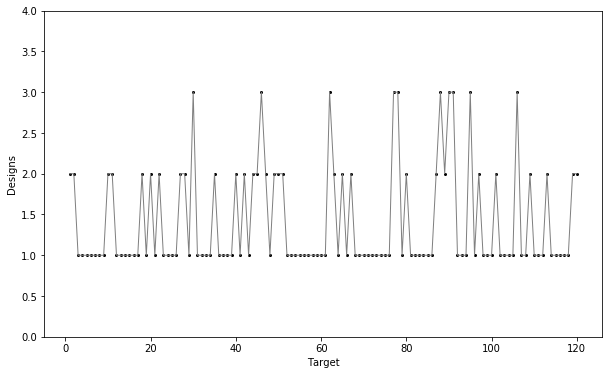

Save results as CSV file? n

New sequence? n

New analysis? n

Bye :-)


In [8]:
# DESIGN PERMUTATIONS

# Enable dynamic graphs mode
#%matplotlib nbagg

# Begin
newAnalysis = 'yes'
while newAnalysis == 'yes':

    # TALENs or DdCBEs?
    design = 0
    while design == 0:
        design = input('\nDesign:\nA. TALENs\nB. Base editors\n')
        if design.lower() == 'exit': sys.exit(0)
        if design not in {'A','a','B','b'}:
            design = 0
            print('Invalid input! Choose A or B.')
        else: design = design.lower()  

    # TALENs for what?
    if design == 'a':
        TALENsFor = 0 
        while TALENsFor == 0:
            TALENsFor = input('\nFind TALEN pairs for:\nA. All potential targets\nB. Targeting a specific site\n')
            if TALENsFor.lower() == 'exit': sys.exit(0)
            if TALENsFor not in {'A','a','B','b'}:
                TALENsFor = 0
                print('Invalid input! Choose A or B')
            else: TALENsFor = TALENsFor.lower()

    # DdCBEs for what?
    if design == 'b':
        baseEditorFor = 0
        while baseEditorFor == 0:
            baseEditorFor = input("\nBase editors for:\nA. All potential 5'-TC-3' targets\nB. Premature termination codon induction\n")
            if baseEditorFor.lower() == 'exit': sys.exit(0)
            if baseEditorFor not in {'A','a','B','b'}:
                baseEditorFor = 0
                print('Invalid input! Choose A or B')
            else: baseEditorFor = baseEditorFor.lower()

    # Design parameters
    default = 0
    while default == 0:
        default = input('\nUse default design parameters? ')
        if default.lower() == 'exit': sys.exit(0)
        if default.lower() not in {'yes','y','no','n'}:
            default = 0
            print("Invalid input! Type 'yes' or 'no'.")     
    # Default paramaters
    if default.lower() in {'yes','y'}:
        leftArmMin, spacerMin, rightArmMin = 15,14,15
        leftArmMax, spacerMax, rightArmMax = 16,16,16
        targetWindow = 4
        print('\nLeft arm minimum length (bp): 15\nLeft arm maximum length (bp): 16\n'\
              '\nSpacer minimum length (bp): 14\nSpacer maximum length (bp): 16\n'\
              '\nRight arm minimum length (bp): 15\nRight arm maximum length (bp): 16\n'\
              '\nTarget window: 4')
    # Custom parameters
    else:
        # Left arm minimum length
        leftArmMin = 0
        while leftArmMin == 0:
            leftArmMin = input('\nLeft arm minimum length (bp): ')
            if leftArmMin.lower() == 'exit': sys.exit(0)
            try:
                leftArmMin = int(leftArmMin)
                if leftArmMin < 5 or leftArmMin > 25:
                    leftArmMin = 0
                    print('Invalid input! Minimum length must be an integer between 5 and 25.')
            except:
                leftArmMin = 0
                print('Invalid input! Minimum length must be an integer between 5 and 25.')
        # Left arm maximum length
        leftArmMax = 0
        while leftArmMax == 0:
            leftArmMax = input('\nLeft arm maximum length (bp): ')
            if leftArmMax.lower() == 'exit': sys.exit(0)
            try:
                leftArmMax = int(leftArmMax)
                if leftArmMax < 5 or leftArmMax > 25:
                    leftArmMax = 0
                    print('Invalid input! Maximum length must be an integer between 5 and 25.')
                elif leftArmMax < leftArmMin:
                    leftArmMax = 0
                    print('Invalid input! Maximum length cannot be less than minimum length.')
            except:
                leftArmMax = 0
                print('Invalid input! Maximum length must be an integer between 5 and 25.')
        # Spacer minimum length
        spacerMin = 0
        while spacerMin == 0:
            spacerMin = input('\nSpacer minimum length (bp): ')
            if spacerMin.lower() == 'exit': sys.exit(0)
            try:
                spacerMin = int(spacerMin)
                if spacerMin < 5 or spacerMin > 25:
                    spacerMin = 0
                    print('Invalid input! Minimum length must be an integer between 5 and 25.')
            except:
                spacerMin = 0
                print('Invalid input! Minimum length must be an integer between 5 and 25.')
        # Spacer maximum length
        spacerMax = 0
        while spacerMax == 0:
            spacerMax = input('\nSpacer maximum length (bp): ')
            if spacerMax.lower() == 'exit': sys.exit(0)
            try:
                spacerMax = int(spacerMax)
                if spacerMax < 5 or spacerMax > 25:
                    spacerMax = 0
                    print('Invalid input! Maximum length must be an integer between 5 and 25.')
                elif spacerMax < spacerMin:
                    spacerMax = 0
                    print('Invalid input! Maximum length cannot be less than minimum length.')
            except:
                spacerMax = 0
                print('Invalid input! Maximum length must be an integer between 5 and 25.')
        # Right arm minimum length
        rightArmMin = 0
        while rightArmMin == 0:
            rightArmMin = input('\nRight arm minimum length (bp): ')
            if rightArmMin.lower() == 'exit': sys.exit(0)
            try:
                rightArmMin = int(rightArmMin)
                if rightArmMin < 5 or rightArmMin > 25:
                    rightArmMin = 0
                    print('Invalid input! Minimum length must be an integer between 5 and 25.')
            except:
                rightArmMin = 0
                print('Invalid input! Minimum length must be an integer between 5 and 25.')
        # Right arm maximum length
        rightArmMax = 0
        while rightArmMax == 0:
            rightArmMax = input('\nRight arm maximum length (bp): ')
            if rightArmMax.lower() == 'exit': sys.exit(0)
            try:
                rightArmMax = int(rightArmMax)
                if rightArmMax < 5 or rightArmMax > 25:
                    rightArmMax = 0
                    print('Invalid input! Maximum length must be an integer between 5 and 25.')
                elif rightArmMax < rightArmMin:
                    rightArmMax = 0
                    print('Invalid input! Maximum length cannot be less than minimum length.')
            except:
                rightArmMax = 0
                print('Invalid input! Maximum length must be an integer between 5 and 25.')
        # Target window
        targetWindow = -1
        while targetWindow == -1:
            targetWindow = input('\nTarget window: ')
            if targetWindow.lower() == 'exit': sys.exit(0)
            try:
                targetWindow = int(targetWindow)
                # If spacer length is even
                if (spacerMax % 2) == 0:
                    if targetWindow < 0 or targetWindow > ((spacerMax-2)/2):
                        targetWindow = -1
                        print('Invalid input! The target window cannot be less than 0 or greater than ' + str(int((spacerMax-2)/2)))
                # If spacer length is odd
                else:
                    if targetWindow < 0 or targetWindow > ((spacerMax-1)/2):
                        targetWindow = -1
                        print('Invalid input! The target window cannot be less than 0 or greater than ' + str(int((spacerMax-1)/2)))
            except:
                targetWindow = -1
                print('Invalid input! The target window must be a non-negative integer.')

    # Begin design analysis
    newSequence, count = True, 0
    while newSequence == True:

        # Analysis number
        count += 1
        print('')
        print('-' * (13 + len(str(count))))
        print('SEQUENCE NO. ' + str(count))
        print('-' * (13 + len(str(count))))

        # Define input
        sequence = 0
        while sequence == 0:
            sequence = input("\nSequence (5'-to-3'): ")
            if sequence.lower() == 'exit': sys.exit(0)
            x, i = sequence.lower(), 0
            while i in range(0,int(len(x))):
                if x[i] not in {'a','c','g','t'}:
                    print('Invalid sequence!')
                    i = len(sequence)
                    sequence = 0
                else: i += 1
        sequence = sequence.lower() # To facilitate the analysis

        # TALEN design
        if design == 'a':
            # All potential targets
            if TALENsFor == 'a':
                coordinates = [[],[]]    
                for i in range(0,len(sequence)-1):
                    coordinates[0].append(sequence[i:i+2].upper())
                    coordinates[1].append(i+1)   
            # Specific site
            elif TALENsFor == 'b':
                # Define the target
                coordinate, coordinates = 0, [[],[]]
                while coordinate == 0:
                    coordinate = input('\nTarget coordinate: ')
                    if coordinate.lower() == 'exit': sys.exit(0)
                    try:
                        coordinate = int(coordinate)
                        if coordinate <= 0:
                            coordinate = 0
                            print('Invalid input! The target coordinate must be a positive integer.')
                        elif coordinate > len(sequence):
                            coordinate = 0
                            print('Invalid input! The target coordinate cannot be outside of the sequence of interest.')
                        else:
                            coordinates[0].append(sequence[coordinate-1:coordinate-1+2].upper())
                            coordinates[1].append(coordinate)
                    except ValueError:
                        coordinate = 0
                        print('Invalid input! The target coordinate must be a positive integer.')
            proceed = True # No need to check for targets

        # DdCBE design        
        elif design == 'b':
            coordinates, targetCount = [[],[]], 0
            # TC motifs
            if baseEditorFor == 'a':
                # Find all target sites
                for i in range(0,int(len(sequence))):
                    if sequence[i:i+2] == 'tc' or sequence[i:i+2] == 'ga':
                        coordinates[0].append(sequence[i:i+2])
                        coordinates[1].append(i+1)
                        targetCount += 1                
            # PTC motifs
            elif baseEditorFor == 'b':
                triplets = []
                for i in range(0,int(len(sequence)/3)):
                    triplets.append(sequence[3*i:3*i+3])
                    # TGA -> TAA -> UAA
                    if triplets[i] == 'tga':
                        coordinates[0].append('TGA')
                        coordinates[1].append(3*i+1)
                        targetCount += 1
                    # CAA -> TAA -> UAA
                    elif triplets[i] == 'caa':
                        if i != 0:
                            if triplets[i-1][2] == 't':
                                coordinates[0].append('TCAA')
                                coordinates[1].append(3*i)
                                targetCount += 1
                    # CAG -> TAG -> UAG
                    elif triplets[i] == 'cag':
                        if i != 0:
                            if triplets[i-1][2] == 't':
                                coordinates[0].append('TCAG')
                                coordinates[1].append(3*i)
                                targetCount += 1   
            proceed = targetCount != 0                    

        # If there are motifs
        if proceed:
            # Identify all possible design permutations
            design_list, RE_list = [[],[],[],[],[],[],[],[]], [[],[]]
            for i in range(0,len(coordinates[0])): # Include all targets
                designCounter = 0 # To count the number of designs
                # Additional conditions to avoid 'index out of range' errors
                condition5end = coordinates[1][i] >= leftArmMax + spacerMax
                condition3end = len(sequence) - coordinates[1][i] >= spacerMax + rightArmMax
                if condition5end and condition3end:  
                    for j in range (spacerMin,spacerMax+1):
                        for k in range(leftArmMin,leftArmMax+1):
                            for l in range(rightArmMin,rightArmMax+1):
                                for m in range(0,j-len(coordinates[0][i])+1): # Slide target through spacer
                                    # Left arm
                                    leftArm = sequence[coordinates[1][i]-2-m-k:coordinates[1][i]-1-m]
                                    # Spacer (capitalize the targetable motif)
                                    spacerX = sequence[coordinates[1][i]-1-m:coordinates[1][i]-1+j-m]
                                    spacer = spacerX[0:m] + spacerX[m:m+len(coordinates[0][i])].upper() + spacerX[m+len(coordinates[0][i]):len(spacerX)]
                                    # Right arm (matches the actual TALE target)
                                    rightArm = sequence[coordinates[1][i]-1+j-m:coordinates[1][i]+j-m+l]
                                    rightArm = reverse_complement(rightArm)                                
                                    # Verify that both arms fulfill the 5'T requirement
                                    if leftArm[0] == 't' and rightArm[0] == 't':
                                        # The motif must be within the 'editing window'
                                        if m+1 >= targetWindow and m+2 <= len(spacer) - targetWindow: 
                                            designCounter += 1 # Increase the design counter
                                            # Append target coordinate, target motif, and design index
                                            design_list[1].append(coordinates[1][i])
                                            design_list[2].append(coordinates[0][i])
                                            design_list[3].append(designCounter)
                                            # Append off-target(s)
                                            if design == 'a': design_list[4].append(0) # TALENs
                                            elif design == 'b': design_list[4].append(spacer.count('ga') + spacer.count('tc')) # DdCBEs
                                            # Append left and right arms
                                            design_list[5].append(leftArm[1:len(leftArm)]) 
                                            design_list[6].append(rightArm[1:len(rightArm)])
                                            # Identify potential loss of restriction sites in the spacer
                                            alignmentStarts, alignmentEnds, REc, REs = 0, 0, 0, ''
                                            for n in range(0,len(fullEnzymes_list)):
                                                # Take advantage of palindromy to decrease computation time
                                                if fullRecognition_list[n] == fullComplements_list[n]:
                                                    # Check if the recognition sequence is in the spacer
                                                    if fullRecognition_list[n] in spacer.lower():
                                                        # Define the limits of the valid alignment range
                                                        alignmentStarts = align(spacer, fullRecognition_list[n])[1] - 1
                                                        alignmentEnds = len(align(spacer, fullRecognition_list[n])[0])
                                                        # Check if the recognition sequence and the target overlap
                                                        if m in range(alignmentStarts, alignmentEnds):
                                                            REc, REs = REc + 1, REs + fullEnzymes_list[n] + ', '
                                                # If the restriction site isn't palindromic
                                                elif fullRecognition_list[n] != fullComplements_list[n]:
                                                    # Check that the recognition site is in the spacer
                                                    if fullRecognition_list[n] in spacer.lower():
                                                        # Define the limits of the valid alignment range 
                                                        alignmentStarts = align(spacer, fullRecognition_list[n])[1] - 1
                                                        alignmentEnds = len(align(spacer, fullRecognition_list[n])[0])
                                                        # Check if the recognition sequence and the target overlap
                                                        if m in range(alignmentStarts, alignmentEnds):
                                                            REc, REs = REc + 1, REs + fullEnzymes_list[n] + ', '
                                                    # Check if the reverse complement is in the spacer
                                                    elif fullComplements_list[n] in spacer.lower():
                                                        # Define the limits of the valid alignment range
                                                        alignmentStarts = align(spacer, fullComplements_list[n])[1] - 1
                                                        alignmentEnds = len(align(spacer, fullComplements_list[n])[0])
                                                        # Check if the recognition sequence and the target overlap
                                                        if m in range(alignmentStarts, alignmentEnds):
                                                            REc, REs = REc + 1, REs + fullEnzymes_list[n] + ', '
                                            # Finishing touches
                                            if REc != 0: REs = REs[:-1]; REs = REs[:-1]
                                            elif REc == 0: REs = 'None'
                                            RE_list[0].append(REs) # Append results
                                            # Ambiguity (only deterministic in base editing)
                                            if design == 'b':
                                                # Identify restriction sites (potential gain)                                   
                                                alignmentStarts, alignmentEnds, REc, REs = 0, 0, 0, ''
                                                # Include the on-target edits (C>T or G>A)
                                                spacerX = spacer
                                                if 'GA' in spacerX: spacerX = spacerX.replace('G','A')
                                                elif 'TC' in spacerX: spacerX = spacerX.replace('C','T')
                                                # Iterate over the enzymes and their recognition sequences
                                                for n in range(0,len(fullEnzymes_list)):
                                                    # Take advantage of palindromy to decrease computation time
                                                    if fullRecognition_list[n] == fullComplements_list[n]:
                                                        # Check if the recognition sequence is in the edited spacer                                        
                                                        if fullRecognition_list[n] in spacerX.lower():
                                                            # Define the limits of the valid alignment range
                                                            alignmentStarts = align(spacerX, fullRecognition_list[n])[1] - 1
                                                            alignmentEnds = len(align(spacerX, fullRecognition_list[n])[0])
                                                            # Check if the recognition sequence and the target overlap
                                                            if m in range(alignmentStarts, alignmentEnds):
                                                                REc, REs = REc + 1, REs + fullEnzymes_list[n] + ', '
                                                    # If the restriction site isn't palindromic
                                                    elif fullRecognition_list[n] != fullComplements_list[n]:
                                                        # Check that the recognition site is in the edited spacer
                                                        if fullRecognition_list[n] in spacerX.lower():
                                                            # Define the limits of the valid alignment range 
                                                            alignmentStarts = align(spacerX, fullRecognition_list[n])[1] - 1
                                                            alignmentEnds = len(align(spacerX, fullRecognition_list[n])[0])
                                                            # Check if the recognition sequence and the target overlap
                                                            if m in range(alignmentStarts, alignmentEnds):
                                                                REc, REs = REc + 1, REs + fullEnzymes_list[n] + ', '
                                                        # Check if the reverse complement is in the edited spacer
                                                        if fullComplements_list[n] in spacerX.lower():
                                                            # Define the limits of the valid alignment range
                                                            alignmentStarts = align(spacerX, fullComplements_list[n])[1] - 1
                                                            alignmentEnds = len(align(spacerX, fullComplements_list[n])[0])
                                                            # Check if the recognition sequence and the target overlap
                                                            if m in range(alignmentStarts, alignmentEnds):
                                                                REc, REs = REc + 1, REs + fullEnzymes_list[n] + ', '
                                                # Finishing touches
                                                if REc != 0: REs = REs[:-1]; REs = REs[:-1]
                                                elif REc == 0: REs = 'None'
                                                RE_list[1].append(REs) # Append results
                                            # Append spacer (with highlights)
                                            for n in {'A','C','G','T'}: spacer = spacer.replace(n, Back.BLUE + n + Style.RESET_ALL)
                                            if design == 'b' and baseEditorFor == 'b':
                                                spacer = spacer.replace('tc', Back.RED + 'tc' + Style.RESET_ALL)
                                                spacer = spacer.replace('ga', Back.RED + 'ga' + Style.RESET_ALL)                                        
                                            design_list[7].append(spacer)

            # Remove deterministic ambiguity
            if design == 'b': 
                # Remove false positives enzymes
                for i in range(0,len(RE_list[0])):
                    s_list = []
                    # Find the false positives
                    if RE_list[0][i] != 'None' and RE_list[1][i] != 'None':
                        s0 = set(RE_list[0][i].replace(' ', '').split(','))
                        s1 = set(RE_list[1][i].replace(' ', '').split(','))
                        s_list = sorted(s0 & s1)
                    # Remove them
                    for j in range(0, len(s_list)):
                        RE_list[0][i] = RE_list[0][i].replace(s_list[j], '')
                        RE_list[1][i] = RE_list[1][i].replace(s_list[j], '')   
                    # Finishing touches
                    if s_list: 
                        for j in range(0,2):
                            # Only commas and spaces
                            p, q = RE_list[j][i] == '', RE_list[j][i] == ', '
                            r = (RE_list[j][i]+RE_list[j][i]).find(RE_list[j][i],1,-1) != -1
                            if p or q or r: RE_list[j][i] = 'None'
                            # Commas, spaces, and letters
                            if RE_list[j][i] != ', ':
                                # Clean up the beginning if it starts with ','
                                if RE_list[j][i][0] == ',':
                                    while RE_list[j][i][0:2] == ', ':
                                        RE_list[j][i] = RE_list[j][i][2:len(RE_list[j][i])] # HERE
                                # Clean up the middle if it contains ', , '
                                if ', , ' in RE_list[j][i]:
                                    while ', , ' in RE_list[j][i]: RE_list[j][i] = RE_list[j][i].replace(', , ', ', ')                                    
                                # Clean up the ending if it ends with ' '
                                if RE_list[j][i][len(RE_list[j][i])-1] == ' ':
                                    while RE_list[j][i][len(RE_list[j][i])-2:len(RE_list[j][i])] == ', ':
                                        RE_list[j][i] = RE_list[j][i][0:len(RE_list[j][i])-2]

            # Correctly append target numbers
            targetCounter = 1
            for i in range(0,len(design_list[1])):
                if i > 0:
                    if design_list[1][i] != design_list[1][i-1]:
                        targetCounter += 1
                design_list[0].append(targetCounter)

            # If there are no viable design permutations
            if not design_list[0]:
                print('\nThere are no viable design permutations!')
                # Ask to try another sequence
                newSequenceX = 0
                while newSequenceX == 0:
                    newSequenceX = input('\nNew sequence? ')
                    if newSequenceX.lower() == 'exit': sys.exit(0)
                    newSequenceX = newSequenceX.lower()
                    if newSequenceX not in {'yes','y','no','n'}:
                        newSequenceX = 0
                        print("Invalid input! Type 'yes' or 'no'.")
                    elif newSequenceX in {'no','n'}: newSequence = False

            # Highlight targetable motifs
            elif design_list[0]:
                targetLength = 0
                for i in range(0,len(design_list[1])):
                    targetLength = len(design_list[2][i])
                    sequence = sequence[:design_list[1][i]-1]+sequence[design_list[1][i]-1:design_list[1][i]-1+targetLength].upper()+sequence[design_list[1][i]-1+targetLength:]           
                # Add blue highlights to the entire sequence
                for i in {'A','C','G','T'}: sequence = sequence.replace(i, Back.BLUE + i + Style.RESET_ALL)
                print('\nSequence (with target/s): ' + sequence + '\n')

                # DISPLAY RESULTS
                
                # Create a dataframe containing the results
                if design == 'a': # TALENs
                    if TALENsFor == 'a': # All targets
                        results_df = pd.DataFrame({'TGT':design_list[0],
                                                   'DSG':design_list[3],
                                                   'POTENTIAL LOSS':RE_list[0],
                                                   'LEFT SEQUENCE':design_list[5],
                                                   'RIGHT SEQUENCE':design_list[6],
                                                   'SPACER SEQUENCE':design_list[7]})
                    elif TALENsFor == 'b': # Specific site
                        results_df = pd.DataFrame({'DSG':design_list[3],
                                                   'POTENTIAL LOSS':RE_list[0],
                                                   'LEFT SEQUENCE':design_list[5],
                                                   'RIGHT SEQUENCE':design_list[6],
                                                   'SPACER SEQUENCE':design_list[7]})
                elif design == 'b': # DdCBEs
                    results_df = pd.DataFrame({'TGT':design_list[0],
                                               'DSG':design_list[3],
                                               'LOSS':RE_list[0],
                                               'GAIN':RE_list[1],
                                               'X':design_list[4],
                                               'LEFT SEQUENCE':design_list[5],
                                               'RIGHT SEQUENCE':design_list[6],
                                               'SPACER SEQUENCE':design_list[7]})
                print(tabulate(results_df, showindex=False, headers=results_df.columns))

                # Visualizing the design permutation distribution
                if design_list[0][-1] > 1:
                    print('\nThere are ' + str(design_list[0][-1]) + ' potential targets and a total of ' + str(len(design_list[0])) + ' design permutations.')
                    print('\nDesign permutation distribution:')
                    fig_size, fig_size[0], fig_size[1] = plt.rcParams["figure.figsize"], 10, 6
                    fig, ax = plt.subplots()
                    ax.set(xlabel = 'Target', ylabel = 'Designs')
                    permutationsGraph_list, subtract = [], 0
                    for i in range(0,len(design_list[0])):
                        if design_list[0][i] > design_list[0][i-1]:
                            permutationsGraph_list.append(i-subtract)
                            subtract = i       
                    permutationsGraph_list.append(design_list[0].count(design_list[0][-1]))
                    permutationsGraph = np.zeros((len(permutationsGraph_list)))
                    for i in range(0,len(permutationsGraph_list)): permutationsGraph[i] = int(permutationsGraph_list[i])
                    i = np.arange(1, design_list[0][-1] + 1, 1)
                    ax.scatter(i, permutationsGraph, c = 'black', s = 4)
                    ax.plot(i, permutationsGraph, c = 'gray', linewidth = 1, linestyle = '-') 
                    ax.set_ylim(0, np.amax(permutationsGraph) + 1)
                    plt.show()
                else: print('\nThere is 1 potential target and ' + str(len(design_list[0])) + ' design permutations.\n')
                
                # Save results
                save, name = 0, 0
                while save == 0:
                    save = input('Save results as CSV file? ')
                    if save.lower() == 'exit': sys.exit(0)
                    save = save.lower()
                    if save not in {'yes','y','no','n'}:
                        save = 0
                        print("Invalid input! Type 'yes' or 'no'.\n")
                    elif save in {'yes','y'}:
                        while name == 0:
                            name = input('\nAlphanumeric filename: ')
                            if name.lower() == 'exit': sys.exit(0)
                            if name.isalnum():
                                # Get rid of colorama markers
                                for i in range(0, len(design_list[7])):
                                    design_list[7][i] = design_list[7][i].replace('\x1b[41m','')
                                    design_list[7][i] = design_list[7][i].replace('\x1b[44m','')
                                    design_list[7][i] = design_list[7][i].replace('\x1b[0m','')
                                # Create a new dataframe without highlights
                                if design == 'a': # TALENs
                                    if TALENsFor == 'a': # All targets
                                        save_df = pd.DataFrame({'TGT':design_list[0],
                                                                'DES':design_list[3],
                                                                'POTENTIAL LOSS':RE_list[0],
                                                                'LEFT SEQUENCE':design_list[5],
                                                                'SPACER SEQUENCE':design_list[7],
                                                                'RIGHT SEQUENCE':design_list[6]})
                                    elif TALENsFor == 'b': # Specific site
                                        save_df = pd.DataFrame({'DES':design_list[3],
                                                                'POTENTIAL LOSS':RE_list[0],
                                                                'LEFT SEQUENCE':design_list[5],
                                                                'SPACER SEQUENCE':design_list[7],
                                                                'RIGHT SEQUENCE':design_list[6]})
                                elif design == 'b': # DdCBEs
                                    save_df = pd.DataFrame({'TGT':design_list[0],
                                                            'DES':design_list[3],
                                                            'LOSS':RE_list[0],
                                                            'GAIN':RE_list[1],
                                                            'X':design_list[4],
                                                            'LEFT SEQUENCE':design_list[5],
                                                            'SPACER SEQUENCE':design_list[7],
                                                            'RIGHT SEQUENCE':design_list[6]})
                                save_df.index += 1 # Start index at 1
                                save_df.to_csv(name + '.csv') # Save dataframe
                            else:
                                name = 0
                                print('Invalid input! File name must be alphanumeric.')

                # After everything worked, ask for new sequence
                newSequenceX = 0
                while newSequenceX == 0:
                    newSequenceX = input('\nNew sequence? ')
                    if newSequenceX.lower() == 'exit': sys.exit(0)
                    newSequenceX = newSequenceX.lower()
                    if newSequenceX not in {'yes','y','no','n'}:
                        newSequenceX = 0
                        print("Invalid input! Type 'yes' or 'no'.")
                    elif newSequenceX in {'no','n'}: newSequence = False

        elif not proceed: print('\nThere are no target sites!') # If there are no targetable motifs
    
    newAnalysis = 0
    while newAnalysis == 0:
        newAnalysis = input('\nNew analysis? ')
        if newAnalysis.lower() == 'exit': sys.exit(0)
        if newAnalysis.lower() not in {'yes','y','no','n'}:
            newAnalysis = 0
            print("Invalid input! Type 'yes' or 'no'.")
        elif newAnalysis.lower() in {'no','n'}: input('\nBye :-)')
        elif newAnalysis.lower() in {'yes','y'}: newAnalysis = 'yes'

In [ ]:
# TALE RVD SEQUENCES

# Number of targets
n = 0
while n == 0:
    n = input('\nNumber of targets: ')
    if n.lower() == 'exit': sys.exit(0)
    try:
        n = int(n)
        if n < 0:
            n = 0
            print('Invalid input! Must be a positive integer.')
    except:
        n = 0
        print('Invalid input! Must be a positive integer.')

# Target sequences and their corresponding RVDs
RVDs_list = ['NI','HD','NN','NG'] # A, C, G, T
motifs_list, target_list = [], []
for i in range(0, n):
    
    # Define the target sequence
    target = 0
    while target == 0:
        target = input('\nTarget sequence ' + str(i+1) + ': ')
        if target.lower() == 'exit': sys.exit(0)
        if target == '':
            target = 0
            print('Invalid input! Must be a DNA sequence.')
        else:
            targetX = target
            target = target.lower()
            i = 0
            while i in range(0, len(targetX)):
                if target[i] not in {'a','c','g','t'}:
                    i = len(target)
                    target = 0
                    print('Invalid input! Must be a DNA sequence.')
                else: i = i + 1
    target_list.append(target)
                    
    # Calculate the RVDs
    specificMotif = ''
    for i in range(0, len(target)):
        if i == len(target) - 1:
            if target[i] == 'a':
                specificMotif = specificMotif + RVDs_list[0]
            elif target[i] == 'c':
                specificMotif = specificMotif + RVDs_list[1]
            elif target[i] == 'g':
                specificMotif = specificMotif + RVDs_list[2]
            elif target[i] == 't':
                specificMotif = specificMotif + RVDs_list[3]         
        else:
            if target[i] == 'a':
                specificMotif = specificMotif + RVDs_list[0] + ' '
            elif target[i] == 'c':
                specificMotif = specificMotif + RVDs_list[1] + ' '
            elif target[i] == 'g':
                specificMotif = specificMotif + RVDs_list[2] + ' '
            elif target[i] == 't':
                specificMotif = specificMotif + RVDs_list[3] + ' ' 
    motifs_list.append(specificMotif)
    
# Display results
df = pd.DataFrame({'Target sequence': target_list, 'Corresponding RVDs': motifs_list})
print('\n' + tabulate(df, showindex=False, headers=df.columns))
print('\nCopy and paste the RVDs directly into: \nhttp://www.talendesign.org/pFUXrecipeInput.php')

# Exit
boolX = False
while boolX == False:
    boolX = True
    input('\nBye :-)')